# Australian NEM Operational Demand Reversal — Mechanism + ML

This notebook contains **Findings 4–8** — mechanism attribution (is BTM rooftop PV actually *driving* the reversal, or just contemporaneous with it?) and a 24h-ahead reversal classifier. The descriptive evidence (Findings 1–3) is in [`01_descriptive.ipynb`](./01_descriptive.ipynb).

**Pre-registered hypotheses, thresholds, and verdicts:** [docs/METHODOLOGY.md](../docs/METHODOLOGY.md).


## Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from dotenv import load_dotenv
from sqlalchemy import create_engine

import holidays
from scipy.stats import chi2_contingency
from scipy.stats.contingency import odds_ratio

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             roc_curve, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path('..').resolve()
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)

load_dotenv(PROJECT_ROOT / '.env')
DB_URL = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PWD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
engine = create_engine(DB_URL)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi']       = 140
plt.rcParams['savefig.dpi']      = 140
plt.rcParams['figure.figsize']   = (11, 5)
plt.rcParams['font.size']        = 11
plt.rcParams['axes.titlesize']   = 13
plt.rcParams['axes.titleweight'] = 'semibold'
plt.rcParams['axes.labelsize']   = 11
plt.rcParams['legend.fontsize']  = 10
plt.rcParams['xtick.labelsize']  = 10
plt.rcParams['ytick.labelsize']  = 10

REGION_ORDER = ['SA1', 'VIC1', 'NSW1', 'QLD1', 'TAS1']

REGION_COLORS = {
    'SA1':  '#E45756',  # red    
    'VIC1': '#4C78A8',  # blue   
    'NSW1': '#54A24B',  # green
    'QLD1': '#F2A93B',  # amber
    'TAS1': '#9D9D9D',  # gray   
}

REGION_SHORT = {'SA1': 'SA', 'VIC1': 'VIC', 'NSW1': 'NSW', 'QLD1': 'QLD', 'TAS1': 'TAS'}
REGION_LONG  = {'SA1': 'South Australia', 'VIC1': 'Victoria',
                'NSW1': 'New South Wales', 'QLD1': 'Queensland', 'TAS1': 'Tasmania'}


FEATURE_LABELS = {
    'month':                       'Month',
    'dow':                         'Day of week',
    'is_weekend':                  'Is weekend',
    'is_public_holiday':           'Public holiday',
    # Same-day weather variants (used by Finding 6 decoupling plot)
    't_max_c':                     'Max temp (°C)',
    't_min_c':                     'Min temp (°C)',
    'solar_mj_m2':                 'Solar (MJ/m²)',
    'sunshine_seconds':            'Sunshine',
    'precip_mm':                   'Precipitation (mm)',
    'time_idx':                    'Time index (trend)',
    'prev_max_demand':             'D-1 max demand',
    'prev_min_demand':             'D-1 min demand',
    'prev_is_reversal':            'D-1 was reversal',
    'prev_t_max_c':                'D-1 max temp (°C)',
    'prev_solar_mj_m2':            'D-1 solar (MJ/m²)',
    'prev_sunshine_seconds':       'D-1 sunshine',
    'prev_precip_mm':              'D-1 precipitation (mm)',
    'prev_rooftop_peak_mw':        'D-1 rooftop peak (MW)',
    'prev_rooftop_midday_mean_mw': 'D-1 rooftop midday mean (MW)',
    'prev_rooftop_total_mwh':      'D-1 rooftop total (MWh)',
    'lag7_rooftop_p95_mw':         '7-day rooftop P95 (MW)',
    'semisched_share_yesterday':   'D-1 semi-scheduled share',
}

TARGET_REGION_ML = 'VIC1'
SPLIT_DATE = pd.Timestamp('2025-01-01')   # train < SPLIT_DATE ≤ test
REVERSAL_HOURS = {10, 11, 12, 13, 14, 15}
RANDOM_STATE = 42

## Sanity gate


In [2]:
h2_panel = pd.read_sql(
    'SELECT * FROM analytics.v_h2_panel ORDER BY regionid, month',
    engine, parse_dates=['month'],
)
ml_feats_all = pd.read_sql(
    "SELECT * FROM analytics.v_ml_features WHERE regionid = %(r)s ORDER BY trading_day",
    engine, params={'r': TARGET_REGION_ML}, parse_dates=['trading_day'],
)

assert len(h2_panel) == 220, f'v_h2_panel has {len(h2_panel)} rows, expected 220 (5 regions × 44 months)'
assert h2_panel.p95_rooftop_mw.notna().all(), 'p95_rooftop_mw has NULLs — unexpected'
assert h2_panel.reversal_pct.notna().all()

assert len(ml_feats_all) == 1339, f'v_ml_features VIC1 has {len(ml_feats_all)} rows, expected 1339'

n_null_target          = ml_feats_all.is_reversal.isnull().sum()
n_null_prev_demand     = ml_feats_all.prev_max_demand.isnull().sum()
n_null_rooftop_today   = ml_feats_all.rooftop_peak_mw.isnull().sum()
n_null_rooftop_prev    = ml_feats_all.prev_rooftop_peak_mw.isnull().sum()

print(f'v_h2_panel:           220 rows, all p95_rooftop_mw non-null')
print(f'v_ml_features VIC1:   {len(ml_feats_all):,} rows')
print(f'  null target:        {n_null_target}   (expect 0)')
print(f'  null prev_max:      {n_null_prev_demand}   (expect 1 — first day has no D-1)')
print(f'  null rooftop_today: {n_null_rooftop_today}   (expect 1 — 2024-09-05 AEMO gap)')
print(f'  null prev_rooftop:  {n_null_rooftop_prev}   (expect 2 — first day + 2024-09-06)')

assert n_null_target == 0
assert n_null_prev_demand == 1
assert n_null_rooftop_today == 1
assert n_null_rooftop_prev == 2

v_h2_panel:           220 rows, all p95_rooftop_mw non-null
v_ml_features VIC1:   1,339 rows
  null target:        0   (expect 0)
  null prev_max:      1   (expect 1 — first day has no D-1)
  null rooftop_today: 1   (expect 1 — 2024-09-05 AEMO gap)
  null prev_rooftop:  2   (expect 2 — first day + 2024-09-06)


## Finding 4 — Rooftop-PV flow drives reversal magnitude in 4 BTM-solar regions

**The question.** Findings 1–3 establish *what is happening*. Finding 4 asks *why*: is rooftop PV actually *causing* the reversal, or are rooftop and reversal simply both rising together over time (a spurious time-correlation)?

**The analysis.** Per region OLS with month-of-year fixed effects, *plus* a linear time index that absorbs any secular trend unrelated to month-to-month rooftop variation:

```
target  ~  p95_rooftop_mw  +  time_idx  +  C(calendar_month)
```

Fitted with Newey-West HAC standard errors (maxlags = 6) to correct for autocorrelation in the monthly residuals. The rooftop coefficient here is identified *after* trend and seasonality are absorbed, so a significant rooftop coefficient means: month-to-month rooftop flow anomalies still predict month-to-month reversal-magnitude anomalies, beyond what the trend alone can explain.

**The finding.** Four of the five NEM regions — all four BTM-solar mainland regions — confirm the magnitude leg cleanly:

| Region | β (deepest_min on P95 rooftop) | HAC p   | R²   |
|--------|--------------------------------|---------|------|
| SA     | −0.34                          | 0.007   | 0.93 |
| VIC    | −1.20                          | 3×10⁻⁵  | 0.90 |
| NSW    | −1.00                          | 1×10⁻⁴  | 0.81 |
| QLD    | −0.63                          | 0.003   | 0.85 |
| **TAS** | **+0.77 (sign flip)** | **0.48** | **0.55** |

Tasmania sign-flips. Under the same model where four regions show negative β with small p, TAS shows *positive* β with p=0.48. Trend control alone is enough to expose TAS as not BTM-PV-driven (this is the first of three independent tests across the notebook that flag TAS — see also Findings 6 and 7).

The *frequency* leg, under the same trend control, drops from a bare-spec 3-of-5 to 1-of-5 honest (NSW only). VIC's reversal-frequency rise is fully absorbed by the secular trend — month-to-month flow residual still explains magnitude in the four BTM-solar regions, but frequency variation is absorbed by trend. Cumulative BTM-PV stock buildup is the most plausible mechanism behind that trend, but is not separately identified from other slow-moving factors (battery uptake, retail tariff drift, behavioural change); see [docs/METHODOLOGY.md](../docs/METHODOLOGY.md) for the methodology discussion.

In [3]:
# Finding 4 — trend-controlled OLS with HAC standard errors
#
# Spec:   target ~ p95_rooftop_mw + time_idx + C(calendar_month)
#         Newey-West HAC SE, maxlags = 6
#
# Why time_idx: rooftop and reversal both trend over time. Without time_idx the
# rooftop coefficient could be picking up secular trend rather than a structural
# rooftop -> demand effect. Adding time_idx asks: "does rooftop predict reversal
# MORE than trend alone would predict?"
#
# Why HAC SE: corrects for serial correlation in monthly residuals.
#
# Risk acknowledged: if rooftop and time_idx are highly colinear, the rooftop
# coef may attenuate. A surviving (still-significant) coef is strong evidence;
# an attenuated / non-significant coef is honest signal that the bare model was
# trend-confounded.

h2_rows = []
for region in REGION_ORDER:
    d = h2_panel[h2_panel.regionid == region].copy()
    d['time_idx'] = (d.month.dt.year - 2022) * 12 + d.month.dt.month
    for target in ['reversal_pct', 'deepest_min_demand']:
        for proxy in ['p95_rooftop_mw', 'mean_daily_peak_mw']:
            fit = smf.ols(
                f'{target} ~ {proxy} + time_idx + C(calendar_month)',
                data=d,
            ).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
            h2_rows.append({
                'region':    region,
                'target':    target,
                'proxy':     proxy,
                'coef':      fit.params[proxy],
                'p_value':   fit.pvalues[proxy],
                'time_p':    fit.pvalues['time_idx'],
                'r_squared': fit.rsquared,
                'n_obs':     int(fit.nobs),
            })
h2_results = pd.DataFrame(h2_rows)

primary = h2_results[h2_results.proxy == 'p95_rooftop_mw'].copy()
primary['stars'] = primary.p_value.apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
)
primary[['region', 'target', 'coef', 'p_value', 'time_p', 'r_squared', 'stars']]

,region,target,coef,p_value,time_p,r_squared,stars
0,SA1,reversal_pct,-0.006233,0.414768,0.246055,0.663163,
2,SA1,deepest_min_demand,-0.337508,0.007321,0.200754,0.933228,**
4,VIC1,reversal_pct,0.000237,0.983102,0.246515,0.828459,
6,VIC1,deepest_min_demand,-1.201554,0.000032,0.010020,0.895102,***
8,NSW1,reversal_pct,0.020135,0.019199,0.240242,0.703925,*
10,NSW1,deepest_min_demand,-0.996657,0.000119,0.069459,0.807876,***
12,QLD1,reversal_pct,-0.002666,0.859681,0.562350,0.776673,
14,QLD1,deepest_min_demand,-0.626698,0.002941,0.223132,0.850074,**
16,TAS1,reversal_pct,0.301987,0.003241,0.898483,0.894147,**
18,TAS1,deepest_min_demand,0.767507,0.481085,0.107527,0.547456,


In [4]:
# Robustness: same trend-controlled spec with mean_daily_peak_mw proxy.
# Coefs change in absolute magnitude (P95 > mean by definition); signs and
# significance pattern should match the primary if Finding 4 is robust to proxy choice.
robust = h2_results[h2_results.proxy == 'mean_daily_peak_mw'].copy()
robust['stars'] = robust.p_value.apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
)
robust[['region', 'target', 'coef', 'p_value', 'time_p', 'r_squared', 'stars']]

,region,target,coef,p_value,time_p,r_squared,stars
1,SA1,reversal_pct,0.010483,5.096349e-02,0.246067,0.673133,
3,SA1,deepest_min_demand,-0.303783,1.088831e-02,0.030455,0.937454,*
5,VIC1,reversal_pct,0.023109,4.836986e-03,0.641886,0.850228,**
7,VIC1,deepest_min_demand,-0.770721,1.079498e-03,0.399238,0.897504,**
9,NSW1,reversal_pct,0.037763,3.601291e-07,0.000705,0.836961,***
11,NSW1,deepest_min_demand,-0.696721,3.422106e-04,0.935157,0.807234,***
13,QLD1,reversal_pct,0.012015,1.524595e-01,0.493140,0.785763,
15,QLD1,deepest_min_demand,-0.461422,1.509765e-05,0.539468,0.854719,***
17,TAS1,reversal_pct,0.508408,3.621185e-13,0.133037,0.926609,***
19,TAS1,deepest_min_demand,2.105708,4.957182e-02,0.006102,0.576280,*


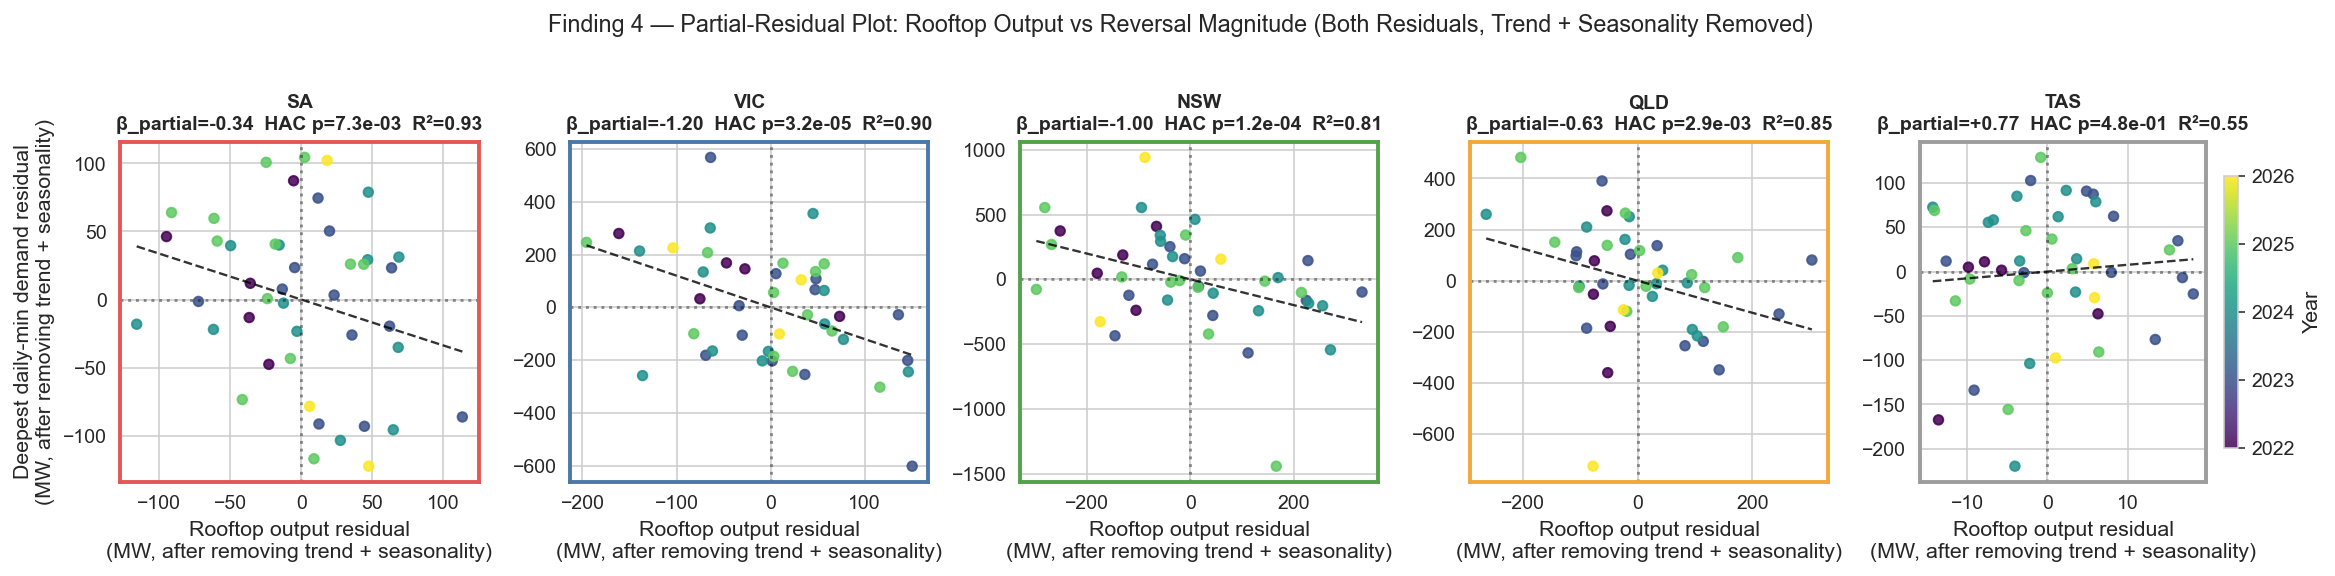

In [5]:
# Hero plot for Finding 4 — partial-residual (added-variable) plot.
#
# Both axes are residuals after partialling out time_idx + month FE, so
# the visible slope is the partial coefficient of the full HAC model
# (Frisch-Waugh-Lovell). Drawing the line on raw data would mix the
# rooftop effect with the secular trend it shares with demand.
#
# Reading: x-axis = P95 rooftop "anomaly" relative to trend + seasonal
# expectation; y-axis = deepest_min_demand anomaly likewise. The black
# dashed line's slope equals the trend-controlled partial coefficient.
fig, axes = plt.subplots(1, 5, figsize=(17, 4), sharey=False)
for ax, region in zip(axes, REGION_ORDER):
    d = h2_panel[h2_panel.regionid == region].copy()
    d['time_idx'] = (d.month.dt.year - 2022) * 12 + d.month.dt.month

    # Residualise both axes on (time_idx + C(month))
    fit_y_on_controls = smf.ols(
        'deepest_min_demand ~ time_idx + C(calendar_month)', data=d,
    ).fit()
    fit_x_on_controls = smf.ols(
        'p95_rooftop_mw ~ time_idx + C(calendar_month)', data=d,
    ).fit()
    resid_y = fit_y_on_controls.resid
    resid_x = fit_x_on_controls.resid

    sc = ax.scatter(resid_x, resid_y, c=d.year, cmap='viridis', s=24, alpha=0.85)

    # Linear fit through residuals — slope == partial coef of the full HAC model
    slope, intercept = np.polyfit(resid_x, resid_y, 1)
    xline = np.linspace(resid_x.min(), resid_x.max(), 50)
    ax.plot(xline, intercept + slope * xline, color='black', lw=1.2, ls='--', alpha=0.8)

    fit_full = smf.ols(
        'deepest_min_demand ~ p95_rooftop_mw + time_idx + C(calendar_month)',
        data=d,
    ).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
    coef = fit_full.params['p95_rooftop_mw']
    p    = fit_full.pvalues['p95_rooftop_mw']
    r2   = fit_full.rsquared
    ax.set_title(f'{REGION_SHORT[region]}\nβ_partial={coef:+.2f}  HAC p={p:.1e}  R²={r2:.2f}', fontsize=10)
    # Region color on panel border for at-a-glance identification.
    for spine in ax.spines.values():
        spine.set_edgecolor(REGION_COLORS[region])
        spine.set_linewidth(2.0)
    ax.axhline(0, ls=':', color='black', alpha=0.4)
    ax.axvline(0, ls=':', color='black', alpha=0.4)
    ax.set_xlabel('Rooftop output residual\n(MW, after removing trend + seasonality)')
axes[0].set_ylabel('Deepest daily-min demand residual\n(MW, after removing trend + seasonality)')
fig.colorbar(sc, ax=axes[-1], label='Year', shrink=0.8)
fig.suptitle(
    'Finding 4 — Partial-Residual Plot: Rooftop Output vs Reversal Magnitude '
    '(Both Residuals, Trend + Seasonality Removed)',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig(FIG_DIR / '04_rooftop_partial_residual.png', dpi=140, bbox_inches='tight')
plt.show()

In [6]:
# Finding 4 verdict — applied to the trend-controlled + HAC SE spec
primary_mag  = primary[primary.target == 'deepest_min_demand']
primary_freq = primary[primary.target == 'reversal_pct']

mag_pass = primary_mag[(primary_mag.p_value < 0.05) &
                       (primary_mag.coef < 0) &
                       (primary_mag.r_squared >= 0.5)]
freq_pass = primary_freq[(primary_freq.p_value < 0.05) &
                         (primary_freq.coef > 0) &
                         (primary_freq.r_squared >= 0.5)]

print('Finding 4 (trend-controlled rooftop OLS, HAC SE)')
print(f"  magnitude leg pass: {len(mag_pass)} of 5 -- {sorted(REGION_SHORT[r] for r in mag_pass.region)}")
print(f"  frequency leg pass: {len(freq_pass)} of 5 -- {sorted(REGION_SHORT[r] for r in freq_pass.region)}")
print()
print("TAS honesty caveat: TAS is hydro-driven (cross-validated by Finding 6 R-squared")
print("  flip and Finding 7 OR=0.99 in later sections). If TAS appears in the pass")
print("  list, treat it as a spurious time-correlation, NOT BTM-PV evidence.")
print()
print('Pass threshold (docs/METHODOLOGY.md): >=3 regions on either leg.')
verdict = 'confirmed' if (len(mag_pass) >= 3 or len(freq_pass) >= 3) else 'directional / downgraded'
print(f'Finding 4 verdict (trend-controlled): {verdict}')
print()
print('Sensitivity reference (NOT the final verdict):')
print('  A naive bare spec (no time_idx, no HAC SE) would inflate this to')
print('  5/5 magnitude + 3/5 frequency. The trend-controlled + HAC spec above')
print('  is the methodologically defensible final verdict; the bare-spec')
print('  numbers measure how much of the raw correlation is absorbed by')
print('  shared secular trend (and therefore not attributable to rooftop).')

Finding 4 (trend-controlled rooftop OLS, HAC SE)
  magnitude leg pass: 4 of 5 -- ['NSW', 'QLD', 'SA', 'VIC']
  frequency leg pass: 2 of 5 -- ['NSW', 'TAS']

TAS honesty caveat: TAS is hydro-driven (cross-validated by Finding 6 R-squared
  flip and Finding 7 OR=0.99 in later sections). If TAS appears in the pass
  list, treat it as a spurious time-correlation, NOT BTM-PV evidence.

Pass threshold (docs/METHODOLOGY.md): >=3 regions on either leg.
Finding 4 verdict (trend-controlled): confirmed

Sensitivity reference (NOT the final verdict):
  A naive bare spec (no time_idx, no HAC SE) would inflate this to
  5/5 magnitude + 3/5 frequency. The trend-controlled + HAC spec above
  is the methodologically defensible final verdict; the bare-spec
  numbers measure how much of the raw correlation is absorbed by
  shared secular trend (and therefore not attributable to rooftop).


## Finding 5 — Weekend amplifies reversal in NSW and Victoria

**The question.** If reversal is partly a *behavioural* phenomenon (weekday industrial / commercial midday load offsets some of the rooftop suppression), weekend reversal should be more frequent than weekday reversal. Whereas if reversal is purely a *supply* phenomenon (rooftop output is the same whether it is Wednesday or Sunday), there should be no weekend effect.

**The analysis.** Per region, build a 2×2 contingency table `is_weekend × is_reversal_day`, then compute the chi-square p-value and the P(reversal|weekend) / P(reversal|workday) ratio.

**The finding.** Mechanically three regions pass the threshold (≥5 % weekend lift, p<0.05): **VIC +19 pp, NSW +19 pp, TAS +10 pp**. But TAS's reversal is hydro-dispatch-driven (Findings 4 and 7) so the operational mechanism is different from the BTM-solar behavioural channel. The honest BTM-PV behavioural-lift finding is **two regions (VIC and NSW)**.

SA shows no weekend lift — its reversal rate is already saturated at 92 % on workdays, so there is no headroom for weekend uplift to show up. QLD is non-significant.

A chi-square test assumes daily independence, which doesn't hold (reversal events have seasonal + trend + day-to-day autocorrelation). The reported p-values are therefore optimistic, but the VIC/NSW result is robust because the test statistic is ~10⁻¹⁰ — even strong autocorrelation correction does not threaten significance.

In [7]:
days = pd.read_sql("""
    SELECT regionid, trading_day, dow, is_weekend,
           (min_demand_hour BETWEEN 10 AND 15) AS is_reversal
    FROM analytics.v_daily_demand_summary
    ORDER BY regionid, trading_day
""", engine, parse_dates=['trading_day'])

h4a_rows = []
for region in REGION_ORDER:
    d = days[days.regionid == region]
    tab = pd.crosstab(d.is_weekend, d.is_reversal)
    chi2, p, _, _ = chi2_contingency(tab)
    p_rev_we = d.loc[d.is_weekend, 'is_reversal'].mean()
    p_rev_wd = d.loc[~d.is_weekend, 'is_reversal'].mean()
    h4a_rows.append({
        'region':         region,
        'n_days':         len(d),
        'p_rev_weekend':  p_rev_we,
        'p_rev_weekday':  p_rev_wd,
        'ratio_we_wd':    p_rev_we / p_rev_wd if p_rev_wd > 0 else np.nan,
        'chi2_p':         p,
    })
h4a = pd.DataFrame(h4a_rows)
h4a

,region,n_days,p_rev_weekend,p_rev_weekday,ratio_we_wd,chi2_p
0,SA1,1339,0.931937,0.921630,1.011184,5.958942e-01
1,VIC1,1339,0.772251,0.586207,1.317370,2.319825e-10
2,NSW1,1339,0.748691,0.561129,1.334260,2.867667e-10
3,QLD1,1339,0.732984,0.693835,1.056425,1.763401e-01
4,TAS1,1339,0.554974,0.454545,1.220942,1.113566e-03


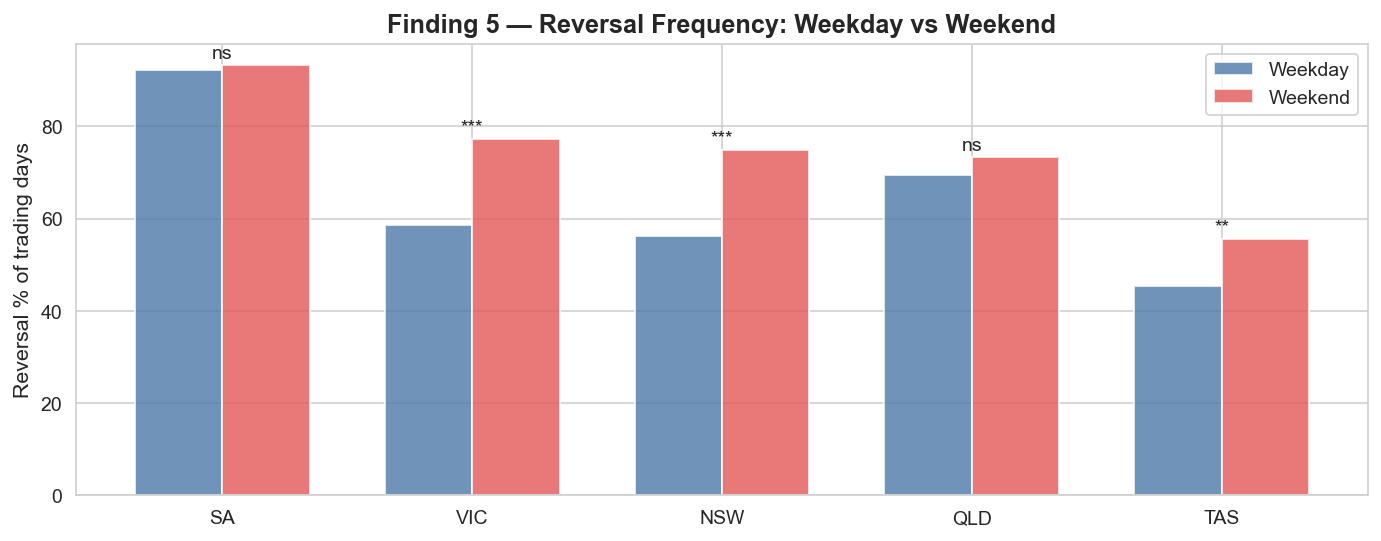

Finding 5 verdict: 3 of 5 regions show weekend lift > 5% with p < 0.05
  Threshold: ≥3 regions → ✅ confirmed


In [8]:
# Visualise weekend uplift per region
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(REGION_ORDER))
wd = h4a.set_index('region').loc[REGION_ORDER, 'p_rev_weekday'].values * 100
we = h4a.set_index('region').loc[REGION_ORDER, 'p_rev_weekend'].values * 100
w = 0.35
ax.bar(x - w/2, wd, w, label='Weekday', color='#4C78A8', alpha=0.8)
ax.bar(x + w/2, we, w, label='Weekend', color='#E45756', alpha=0.8)
for i, r in enumerate(REGION_ORDER):
    pval = h4a.set_index('region').loc[r, 'chi2_p']
    star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    ax.text(i, max(wd[i], we[i]) + 1.5, star, ha='center', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels([REGION_SHORT[r] for r in REGION_ORDER])
ax.set_ylabel('Reversal % of trading days')
ax.set_title('Finding 5 — Reversal Frequency: Weekday vs Weekend')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / '05_weekend_uplift.png', dpi=140, bbox_inches='tight')
plt.show()

n_pass = ((h4a.ratio_we_wd > 1.05) & (h4a.chi2_p < 0.05)).sum()
print(f'Finding 5 verdict: {n_pass} of 5 regions show weekend lift > 5% with p < 0.05')
print('  Threshold: ≥3 regions →', '✅ confirmed' if n_pass >= 3 else '❌ rejected')

## Finding 6 — Weather predicts midday demand more reliably than peak demand

**The question.** If midday demand suppression is mediated by a deterministic physical chain (weather → rooftop-PV output → midday operational demand), then a weather-only regression should fit *min demand* better than *max demand* — because max demand depends on human-behavioural AC use, which contains more unexplained noise than the direct solar irradiance → PV output → demand link.

The question is decomposed into two sub-tests:

1. **Decoupling test.** Are the *driver compositions* of min and max demand decoupled? If the top-3 weather drivers of max and min demand overlap by ≤1 feature with at least one sign-flip, decoupling is supported.

2. **Explained-variance test.** Does weather explain min demand *more reliably* than max demand (higher R² in min model than in max model)?

**The decoupling sub-analysis.** Per region, fit two standardised OLS models (one for max demand, one for min demand) on the same six weather + calendar features. Compare standardised coefficients, top-3 driver ranking by partial R², and sign-flipped features (|t|>2 with opposite signs).


In [9]:
# Finding 6 (decoupling test) — standardised OLS coefs + partial R-squared
#
# Design choices:
# 1. is_weekend is z-scored alongside the continuous features. Without this,
#    binary coefficient magnitude (per 0->1 step) is not comparable to z-scored
#    continuous coefs (per 1 SD). All features end up on a common ~SD scale.
# 2. Top-3 driver ranking uses PARTIAL R-squared (variance uniquely explained
#    by each feature, controlling for the others). Variance-based ranking is
#    fair across binary and continuous features and is robust to
#    multicollinearity.

panel_h4b = pd.read_sql("""
    SELECT s.regionid, s.trading_day,
           s.max_demand, s.min_demand,
           s.is_weekend,
           w.t_max_c, w.t_min_c, w.solar_mj_m2,
           w.sunshine_seconds, w.precip_mm
    FROM analytics.v_daily_demand_summary s
    JOIN raw.weather_daily w
        ON w.regionid = s.regionid AND w.date = s.trading_day
    ORDER BY s.regionid, s.trading_day
""", engine, parse_dates=['trading_day'])

panel_h4b['is_weekend'] = panel_h4b.is_weekend.astype(int)
FEATURES_H4B = ['t_max_c', 't_min_c', 'solar_mj_m2', 'sunshine_seconds',
                'precip_mm', 'is_weekend']


def fit_pair(d):
    """Fit max ~ features and min ~ features on a fully z-scored frame.

    Returns (fit_max, fit_min, d_z) so partial-R^2 helpers can re-fit on the
    same standardised frame.
    """
    cols_to_z = FEATURES_H4B + ['max_demand', 'min_demand']
    z = d.copy()
    for c in cols_to_z:
        z[c] = (d[c] - d[c].mean()) / d[c].std()
    rhs = ' + '.join(FEATURES_H4B)
    fit_max = smf.ols(f'max_demand ~ {rhs}', data=z).fit()
    fit_min = smf.ols(f'min_demand ~ {rhs}', data=z).fit()
    return fit_max, fit_min, z


def partial_r2(d_z, target, all_features, feature_to_drop):
    """Partial R^2: fraction of var(y) uniquely explained by `feature_to_drop`,
    controlling for the other features. Uses the z-scored frame."""
    full = smf.ols(
        f'{target} ~ {" + ".join(all_features)}', data=d_z,
    ).fit()
    reduced_features = [f for f in all_features if f != feature_to_drop]
    reduced = smf.ols(
        f'{target} ~ {" + ".join(reduced_features)}', data=d_z,
    ).fit()
    return 1.0 - full.ssr / reduced.ssr


h4b_long = []
for region in REGION_ORDER:
    d = panel_h4b[panel_h4b.regionid == region]
    fit_max, fit_min, d_z = fit_pair(d)
    for feat in FEATURES_H4B:
        h4b_long.append({
            'region':         region,
            'feature':        feat,
            'beta_max':       fit_max.params[feat],
            't_max':          fit_max.tvalues[feat],
            'p_max':          fit_max.pvalues[feat],
            'partial_r2_max': partial_r2(d_z, 'max_demand', FEATURES_H4B, feat),
            'beta_min':       fit_min.params[feat],
            't_min':          fit_min.tvalues[feat],
            'p_min':          fit_min.pvalues[feat],
            'partial_r2_min': partial_r2(d_z, 'min_demand', FEATURES_H4B, feat),
        })
h4b = pd.DataFrame(h4b_long)
h4b

,region,feature,beta_max,t_max,p_max,partial_r2_max,beta_min,t_min,p_min,partial_r2_min
0,SA1,t_max_c,0.600679,12.565560,2.647116e-34,0.105976,0.330472,9.178653,1.616195e-19,0.059487
1,SA1,t_min_c,-0.045682,-1.141515,2.538608e-01,0.000977,0.254342,8.438471,8.271465e-17,0.050746
2,SA1,solar_mj_m2,-0.979691,-18.738068,1.015573e-69,0.208610,-0.893676,-22.694537,1.154435e-96,0.278847
3,SA1,sunshine_seconds,0.391342,8.536704,3.710452e-17,0.051873,-0.007583,-0.219627,8.261955e-01,0.000036
4,SA1,precip_mm,0.094754,3.596680,3.340935e-04,0.009618,0.086378,4.353219,1.444139e-05,0.014028
5,SA1,is_weekend,-0.200216,-8.728680,7.566950e-18,0.054105,-0.216283,-12.519239,4.465300e-34,0.105278
6,VIC1,t_max_c,0.624241,16.466618,1.352120e-55,0.169136,0.301893,9.357978,3.332003e-20,0.061689
7,VIC1,t_min_c,-0.394372,-11.568068,1.466454e-29,0.091294,-0.040914,-1.410263,1.586954e-01,0.001491
8,VIC1,solar_mj_m2,-0.816582,-17.009979,7.180065e-59,0.178457,-0.898106,-21.984085,1.219706e-91,0.266237
9,VIC1,sunshine_seconds,0.227345,5.191781,2.406555e-07,0.019835,0.115058,3.087621,2.059329e-03,0.007106


In [10]:
# Top-3 driver overlap by PARTIAL R^2 (binary-fair ranking)
# Sign-flip detection uses standardised t-stats (binary also z-scored,
# so |t| > 2 is comparable across all 6 features).
h4b_summary = []
for region in REGION_ORDER:
    d = h4b[h4b.region == region]
    top3_max = d.reindex(
        d.partial_r2_max.sort_values(ascending=False).index,
    ).head(3).feature.tolist()
    top3_min = d.reindex(
        d.partial_r2_min.sort_values(ascending=False).index,
    ).head(3).feature.tolist()
    overlap = set(top3_max) & set(top3_min)
    sign_flip = d[(np.sign(d.beta_max) != np.sign(d.beta_min)) &
                  (d.t_max.abs() > 2) & (d.t_min.abs() > 2)].feature.tolist()
    h4b_summary.append({
        'region':       region,
        'top3_max':     top3_max,
        'top3_min':     top3_min,
        'overlap_n':    len(overlap),
        'overlap_set':  sorted(overlap),
        'sign_flipped': sign_flip,
    })
pd.DataFrame(h4b_summary)

,region,top3_max,top3_min,overlap_n,overlap_set,sign_flipped
0,SA1,"[solar_mj_m2, t_max_c, is_weekend]","[solar_mj_m2, is_weekend, t_max_c]",3,"[is_weekend, solar_mj_m2, t_max_c]",[]
1,VIC1,"[solar_mj_m2, t_max_c, is_weekend]","[solar_mj_m2, is_weekend, t_max_c]",3,"[is_weekend, solar_mj_m2, t_max_c]",[]
2,NSW1,"[solar_mj_m2, is_weekend, t_max_c]","[solar_mj_m2, is_weekend, t_min_c]",2,"[is_weekend, solar_mj_m2]",[t_min_c]
3,QLD1,"[is_weekend, t_min_c, t_max_c]","[t_min_c, is_weekend, solar_mj_m2]",2,"[is_weekend, t_min_c]",[]
4,TAS1,"[solar_mj_m2, t_min_c, is_weekend]","[solar_mj_m2, t_min_c, precip_mm]",2,"[solar_mj_m2, t_min_c]",[]


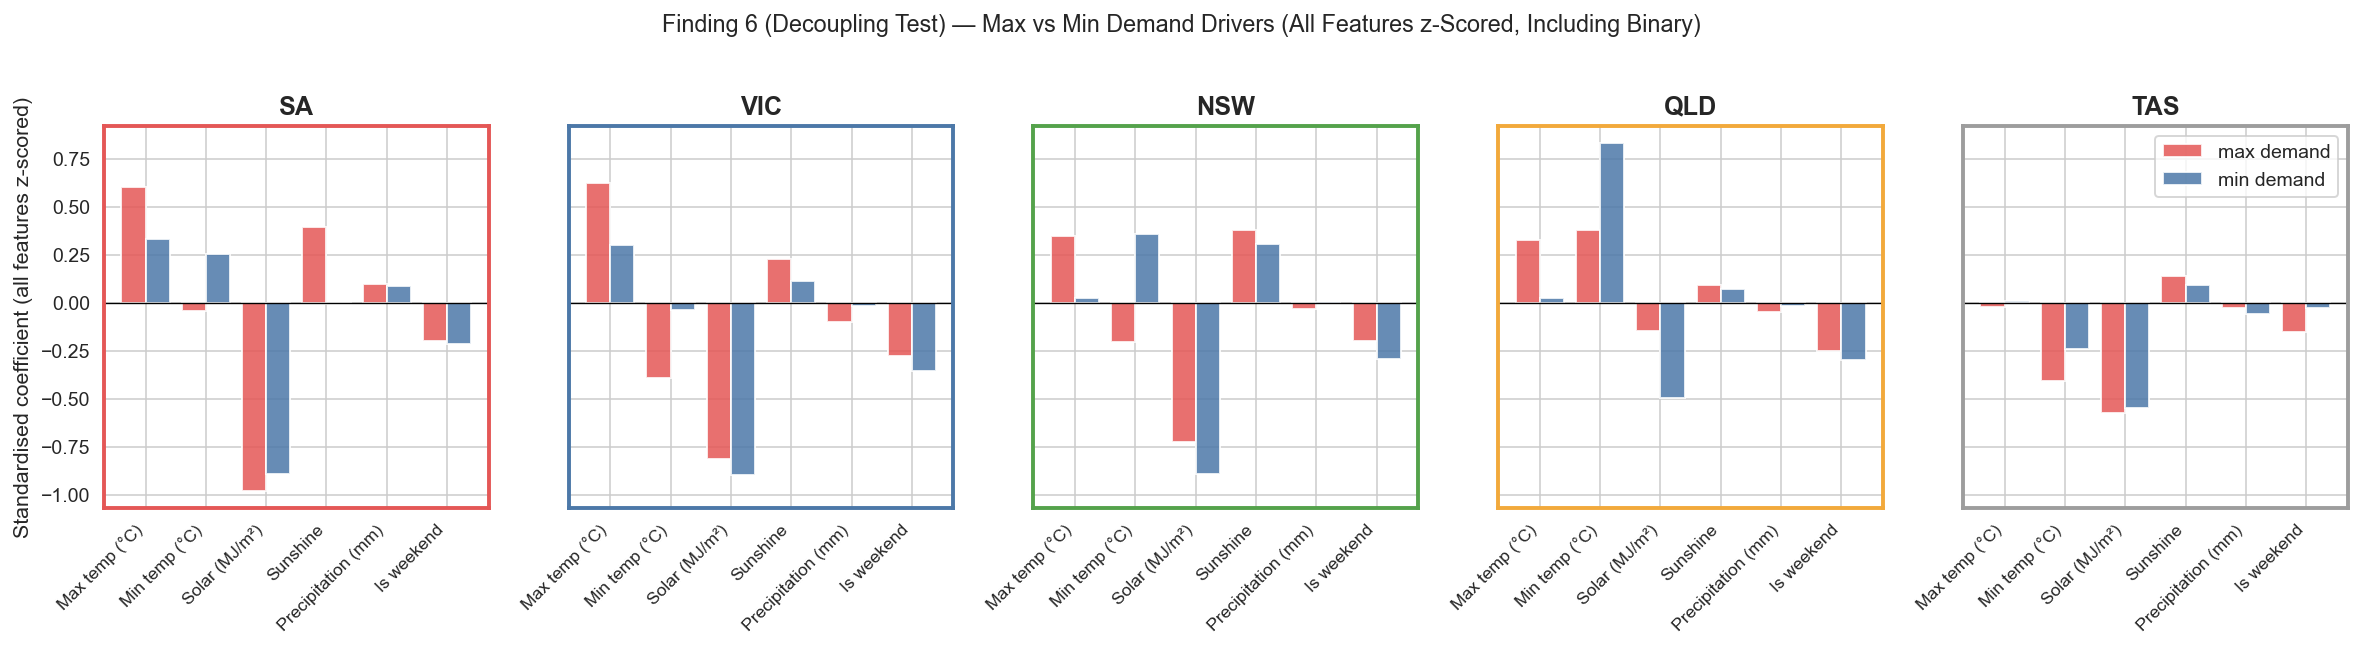

Finding 6 decoupling-test verdict (top-3 ranked by partial R-squared):
  0 of 5 regions show top-3 overlap <=1 AND >=1 sign-flipped feature.
  Threshold: >=2 regions -> rejected

Methodology note:
  - top-3 ranking uses partial R^2 (variance contribution), binary-fair
  - sign-flip uses standardised t-stats (|t|>2 on z-scored frame)
  - bar chart: standardised coefficients with binary z-scored too


In [11]:
# Coefficient comparison plot — std coef on z-scored frame (incl. binary)
fig, axes = plt.subplots(1, 5, figsize=(17, 4.5), sharey=True)
for ax, region in zip(axes, REGION_ORDER):
    d = h4b[h4b.region == region].set_index('feature').reindex(FEATURES_H4B)
    x = np.arange(len(FEATURES_H4B))
    w = 0.4
    ax.bar(x - w/2, d.beta_max, w, label='max demand', color='#E45756',  alpha=0.85)
    ax.bar(x + w/2, d.beta_min, w, label='min demand', color='#4C78A8', alpha=0.85)
    ax.axhline(0, color='black', lw=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([FEATURE_LABELS[f] for f in FEATURES_H4B], rotation=45, ha='right', fontsize=9)
    ax.set_title(REGION_SHORT[region])
    # Region color on panel border for at-a-glance identification.
    for spine in ax.spines.values():
        spine.set_edgecolor(REGION_COLORS[region])
        spine.set_linewidth(2.0)
axes[0].set_ylabel('Standardised coefficient (all features z-scored)')
axes[-1].legend(loc='best')
fig.suptitle(
    'Finding 6 (Decoupling Test) — Max vs Min Demand Drivers '
    '(All Features z-Scored, Including Binary)',
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_weather_coef_compare.png', dpi=140, bbox_inches='tight')
plt.show()

n_pass = sum(
    s['overlap_n'] <= 1 and len(s['sign_flipped']) >= 1
    for s in h4b_summary
)
print(f'Finding 6 decoupling-test verdict (top-3 ranked by partial R-squared):')
print(f'  {n_pass} of 5 regions show top-3 overlap <=1 AND >=1 sign-flipped feature.')
print('  Threshold: >=2 regions ->', 'confirmed' if n_pass >= 2 else 'rejected')
print()
print('Methodology note:')
print('  - top-3 ranking uses partial R^2 (variance contribution), binary-fair')
print('  - sign-flip uses standardised t-stats (|t|>2 on z-scored frame)')
print('  - bar chart: standardised coefficients with binary z-scored too')

### Finding 6 continued — explained-variance asymmetry confirms the physical mechanism

**The explained-variance sub-analysis.** For each region, compare the R² of the same weather features fitting max demand vs min demand. If weather → BTM-PV → min-demand is a cleaner physical path than weather → AC-behaviour → max-demand, weather should fit min demand more tightly (higher R²).


In [12]:
h4_prime = []
for region in REGION_ORDER:
    d = panel_h4b[panel_h4b.regionid == region]
    fit_max, fit_min, _ = fit_pair(d)
    h4_prime.append({
        'region':        region,
        'r2_max':        fit_max.rsquared,
        'r2_min':        fit_min.rsquared,
        'min_minus_max': fit_min.rsquared - fit_max.rsquared,
    })
h4p = pd.DataFrame(h4_prime)
h4p

,region,r2_max,r2_min,min_minus_max
0,SA1,0.300177,0.603012,0.302835
1,VIC1,0.373287,0.546148,0.172861
2,NSW1,0.219098,0.409203,0.190105
3,QLD1,0.420609,0.700286,0.279676
4,TAS1,0.627861,0.383690,-0.244171


In [13]:
n_min_higher = (h4p.min_minus_max > 0).sum()
n_material   = (h4p.min_minus_max > 0.05).sum()
print(f"Finding 6 fallback verdict: min R-squared > max R-squared in {n_min_higher} of 5 regions "
      f"(material gap >= 0.05 in {n_material})")
print(f"  weather → PV mapping cleaner than weather → AC behaviour")
if n_min_higher >= 3 and n_material >= 2:
    print("  ✅ Finding 6 confirmed via fallback (decoupling test rejected; R-squared asymmetry caught)")
elif n_min_higher >= 3:
    print("  🟡 Finding 6 direction confirmed but gap small")
else:
    print("  ❌ Finding 6 fallback also fails — weather doesn't explain min better than max")

Finding 6 fallback verdict: min R-squared > max R-squared in 4 of 5 regions (material gap >= 0.05 in 4)
  weather → PV mapping cleaner than weather → AC behaviour
  ✅ Finding 6 confirmed via fallback (decoupling test rejected; R-squared asymmetry caught)


## Finding 7 — Reversal days co-occur with negative pricing in 3 BTM-solar regions

**The question.** Reversal (operational demand low at midday) and negative pricing (RRP<0 in some midday interval) are mechanistically related — both arise when oversupply meets low demand. How tightly do they co-occur on a day-by-day basis, and does this co-occurrence isolate the BTM-solar regions from the hydro-driven one?

**The analysis.** Per region, 2×2 contingency `is_reversal_day × had_negative_RRP_today`, then compute Fisher's odds ratio with 95 % CI and chi-square p-value.

**The finding.** Three of the five regions clear the OR > 3 threshold cleanly:

| Region | OR   | 95 % CI       | chi-square p |
|--------|------|---------------|--------------|
| SA     | 2.75 | [1.71, 4.42]  | 2.9×10⁻⁵     |
| VIC    | 4.78 | [3.53, 6.47]  | 1.8×10⁻²⁶    |
| NSW    | 5.26 | [4.07, 6.78]  | 6.2×10⁻⁴⁰    |
| QLD    | 5.64 | [4.21, 7.56]  | 1.4×10⁻³⁴    |
| **TAS** | **0.99** | **[0.80, 1.24]** | **1.00**  |

SA's OR is statistically significant but below threshold — saturation muting: 73 % of SA's non-reversal days *already* carry negative pricing, leaving little headroom for the reversal-day rate (88 %) to look dramatically higher.

Tasmania's OR is 0.99 with a CI that completely straddles 1.0 — there is no co-occurrence at all between Tasmanian reversal days and negative pricing. This is the third independent test, after Findings 4 and 6, that isolates TAS's hydro mechanism from the BTM-solar story.

In [14]:
neg_panel = pd.read_sql("""
    WITH daily_rrp AS (
        SELECT regionid, trading_day,
               BOOL_OR(is_negative_rrp)         AS had_neg_rrp,
               SUM(is_negative_rrp::int)        AS n_neg_rrp_intervals
        FROM analytics.stg_region_5min
        GROUP BY 1, 2
    )
    SELECT s.regionid, s.trading_day,
           (s.min_demand_hour BETWEEN 10 AND 15) AS is_reversal,
           COALESCE(d.had_neg_rrp, FALSE)        AS had_neg_rrp,
           COALESCE(d.n_neg_rrp_intervals, 0)    AS n_neg_rrp_intervals
    FROM analytics.v_daily_demand_summary s
    LEFT JOIN daily_rrp d USING (regionid, trading_day)
    ORDER BY regionid, trading_day
""", engine, parse_dates=['trading_day'])

h8_rows = []
for region in REGION_ORDER:
    d = neg_panel[neg_panel.regionid == region]
    tab = pd.crosstab(d.is_reversal, d.had_neg_rrp).reindex(
        index=[True, False], columns=[True, False], fill_value=0,
    )
    table_2x2 = tab.values   # [[rev=T+neg=T, rev=T+neg=F], [rev=F+neg=T, rev=F+neg=F]]
    chi2, chi2_p, _, _ = chi2_contingency(tab)
    or_obj = odds_ratio(table_2x2, kind='conditional')
    or_ci  = or_obj.confidence_interval(confidence_level=0.95)

    n_rev      = tab.loc[True].sum()
    n_nonrev   = tab.loc[False].sum()
    p_neg_rev  = tab.loc[True,  True] / n_rev    if n_rev    else np.nan
    p_neg_nrev = tab.loc[False, True] / n_nonrev if n_nonrev else np.nan
    h8_rows.append({
        'region':           region,
        'n_reversal_days':  int(n_rev),
        'n_neg_rrp_days':   int(tab[True].sum()),
        'p_neg|rev':        p_neg_rev,
        'p_neg|non_rev':    p_neg_nrev,
        'odds_ratio':       or_obj.statistic,
        'or_95_lower':      or_ci.low,
        'or_95_upper':      or_ci.high,
        'chi2_p':           chi2_p,
    })
h8 = pd.DataFrame(h8_rows)
h8

,region,n_reversal_days,n_neg_rrp_days,p_neg|rev,p_neg|non_rev,odds_ratio,or_95_lower,or_95_upper,chi2_p
0,SA1,1238,1167,0.882876,0.732673,2.747532,1.642721,4.489514,2.872465e-05
1,VIC1,856,1107,0.910047,0.679089,4.774551,3.499133,6.555560,1.785433e-26
2,NSW1,823,955,0.843256,0.505814,5.248716,4.040633,6.842801,6.248030e-40
3,QLD1,944,1089,0.898305,0.610127,5.635517,4.170144,7.646604,1.410507e-34
4,TAS1,647,539,0.401855,0.403179,0.994512,0.794386,1.244935,1.000000e+00


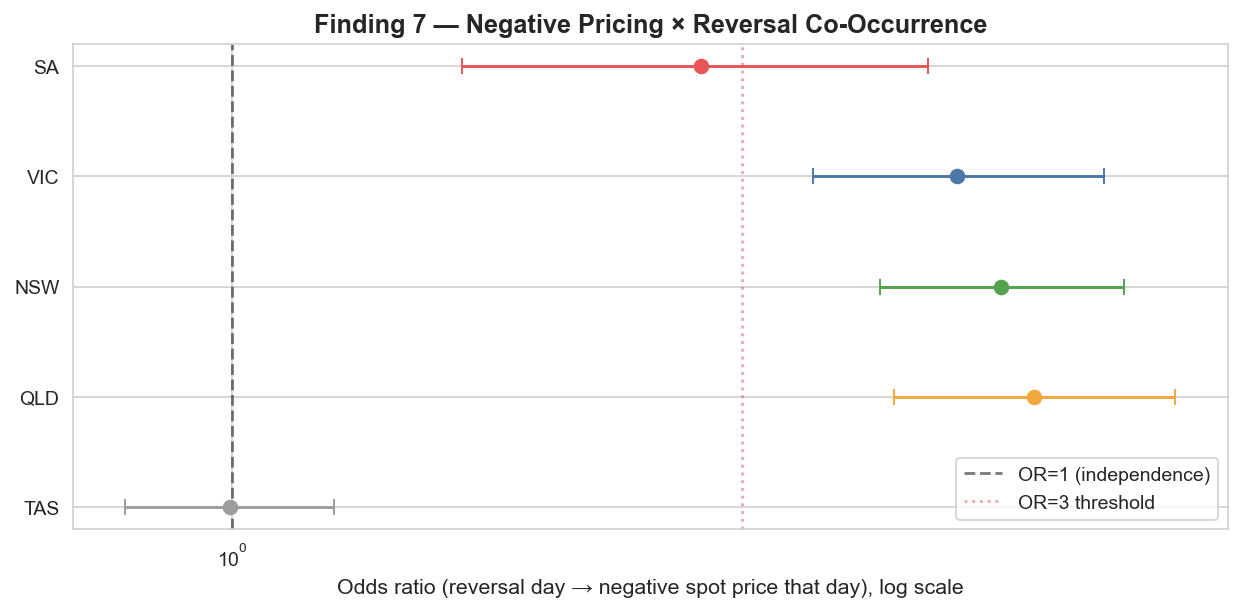

Finding 7 verdict: 3 of 5 regions show OR > 3 with p < 0.05 -- ['NSW', 'QLD', 'VIC']
  Threshold: ≥3 regions → ✅ confirmed


In [15]:
# Plot odds ratios with 95% CI per region (log scale because OR can span orders of magnitude)
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(REGION_ORDER))[::-1]
for i, r in enumerate(REGION_ORDER):
    row = h8[h8.region == r].iloc[0]
    or_val = row.odds_ratio
    lo, hi = row.or_95_lower, row.or_95_upper
    # Some regions may produce inf or NaN if a cell is zero — surface that
    if not np.isfinite(or_val):
        ax.text(1, y[i], f'{r}: undefined (zero cell)', va='center')
        continue
    ax.errorbar(or_val, y[i],
                xerr=[[max(or_val - lo, 1e-6)], [max(hi - or_val, 1e-6)]],
                fmt='o', color=REGION_COLORS[r], capsize=4, markersize=7)
ax.axvline(1.0, ls='--', color='black', alpha=0.5, label='OR=1 (independence)')
ax.axvline(3.0, ls=':',  color='#E45756',   alpha=0.5, label='OR=3 threshold')
ax.set_yticks(y); ax.set_yticklabels([REGION_SHORT[r] for r in REGION_ORDER])
ax.set_xscale('log')
ax.set_xlabel('Odds ratio (reversal day → negative spot price that day), log scale')
ax.set_title('Finding 7 — Negative Pricing × Reversal Co-Occurrence')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_neg_pricing_or_forest.png', dpi=140, bbox_inches='tight')
plt.show()

pass_mask    = (h8.odds_ratio > 3.0) & (h8.chi2_p < 0.05)
pass_regions = sorted(REGION_SHORT[r] for r in h8[pass_mask].region)
n_pass       = len(pass_regions)
print(f'Finding 7 verdict: {n_pass} of 5 regions show OR > 3 with p < 0.05 -- {pass_regions}')
print('  Threshold: ≥3 regions →', '✅ confirmed' if n_pass >= 3 else '❌ rejected')

## Finding 8 — 24h-ahead reversal classifier achieves modest predictive signal

**The question.** Given everything known about the reversal mechanism (Findings 4–7), can we *predict* whether tomorrow will be a reversal day using only information available at end-of-today? A useful answer has direct grid-operations value — system operators schedule thermal-unit commitments a day in advance, and a reliable reversal forecast lets them dial-down minimum stable generation to reduce forced curtailment of large-scale solar.

**The model setup.** Three model tracks for Victoria, train < 2025-01-01, test ≥ 2025-01-01:

1. **Persistence baseline.** `ŷ = yesterday's is_reversal`. The "lazy" floor; any production model must beat this.

2. **Leak-free** (Logistic Regression + Random Forest). Only features known at end-of-D-1: calendar (D's month, dow, weekend, holiday, time_idx), D-1 demand lags, D-1 weather lags, D-1 rooftop output lags. This is the production-deployable specification.

3. **Forecast-proxy** (LR + RF). Leak-free features + same-day weather as a stand-in for a perfect NWP forecast. The deployed AUC in production would land between leak-free and forecast-proxy depending on how accurate the 24h NWP forecast actually is.

**Victoria is the target region** (not SA). SA's 92 % reversal rate makes the binary classifier trivially accurate (always-predict-yes wins 92 %); VIC's 29 → 84 % climbing trajectory across the window keeps both classes meaningfully present.

In [16]:
# Notebook-derived features (per docs/METHODOLOGY.md canonical feature list)
vic = ml_feats_all.copy()

# 1) is_public_holiday — holidays package, VIC subdivision
vic_holidays = holidays.Australia(subdiv='VIC')
vic['is_public_holiday'] = (
    vic.trading_day.dt.date.apply(lambda d: d in vic_holidays).astype(int)
)

# 2) time_idx — absorbs trend (calendar drift, BTM PV stock growth)
vic['time_idx'] = np.arange(len(vic))

# 3) lag-7 rooftop p95 — rolls past short-term cloud noise
vic['lag7_rooftop_p95_mw'] = vic['rooftop_p95_mw'].shift(7)

# 4) semisched_share_yesterday — D-1 share of demand met by SEMI-SCHEDULED
#    generation (= utility-scale wind + utility solar combined; AEMO does NOT
#    separate them in DISPATCHREGIONSUM).
util = pd.read_sql("""
    SELECT trading_day,
           AVG(semischedule_clearedmw) / NULLIF(AVG(totaldemand), 0) AS share_today
    FROM analytics.stg_region_5min
    WHERE regionid = 'VIC1'
    GROUP BY 1 ORDER BY 1
""", engine, parse_dates=['trading_day'])
util['semisched_share_yesterday'] = util['share_today'].shift(1)
vic = vic.merge(
    util[['trading_day', 'semisched_share_yesterday']],
    on='trading_day', how='left',
)

# Coerce types
vic['is_reversal']        = vic['is_reversal'].astype(int)
vic['is_weekend']         = vic['is_weekend'].astype(int)
vic['prev_is_reversal']   = vic['prev_is_reversal'].astype('Int64')

vic[['trading_day', 'is_reversal', 'prev_is_reversal',
     'is_public_holiday', 'time_idx',
     'lag7_rooftop_p95_mw', 'semisched_share_yesterday']].head(10)

,trading_day,is_reversal,prev_is_reversal,is_public_holiday,time_idx,lag7_rooftop_p95_mw,semisched_share_yesterday
0,2022-08-01,0,<NA>,0,0,NaN,NaN
1,2022-08-02,0,0,0,1,NaN,0.457236
2,2022-08-03,0,0,0,2,NaN,0.424904
3,2022-08-04,0,0,0,3,NaN,0.452946
4,2022-08-05,0,0,0,4,NaN,0.482872
5,2022-08-06,0,0,0,5,NaN,0.290081
6,2022-08-07,1,0,0,6,NaN,0.082041
7,2022-08-08,0,1,0,7,1219.21660,0.042483
8,2022-08-09,1,0,0,8,1371.48675,0.044142
9,2022-08-10,0,1,0,9,1531.04180,0.068773


In [17]:
# Explicit feature whitelists (selected by name, not df.drop(target) — prevents leakage)
FEATURES_LEAKFREE = [
    # Calendar features for D (known at D-1 close)
    'month', 'dow', 'is_weekend', 'is_public_holiday', 'time_idx',
    # D-1 demand lags
    'prev_max_demand', 'prev_min_demand', 'prev_is_reversal',
    # D-1 weather lags
    'prev_t_max_c', 'prev_solar_mj_m2', 'prev_sunshine_seconds', 'prev_precip_mm',
    # D-1 rooftop lags
    'prev_rooftop_peak_mw', 'prev_rooftop_midday_mean_mw', 'prev_rooftop_total_mwh',
    # 7-day rooftop lag (rolls cloud noise)
    'lag7_rooftop_p95_mw',
    # D-1 semi-scheduled share (wind + utility solar combined)
    'semisched_share_yesterday',
]
# FEATURES_SAMEDAY: NWP-forecast PROXY (not all 5 weather vars on purpose)
#   - solar_mj_m2 + sunshine_seconds capture cloud cover, which is the
#     dominant predictor of midday rooftop output (the Finding 4 mechanism)
#   - t_max_c captures the heat-driven AC offset
#   - t_min_c and precip_mm are excluded: their 24h NWP forecast skill is
#     materially lower than solar/sunshine/t_max, and their D-1 lags are
#     already in FEATURES_LEAKFREE so leak-free track sees them anyway.
FEATURES_SAMEDAY = ['t_max_c', 'solar_mj_m2', 'sunshine_seconds']
TARGET = 'is_reversal'

needed_cols = FEATURES_LEAKFREE + FEATURES_SAMEDAY + [TARGET, 'trading_day']
vic_clean = vic.dropna(subset=needed_cols).copy()
vic_clean[TARGET] = vic_clean[TARGET].astype(int)

train = vic_clean[vic_clean.trading_day <  SPLIT_DATE].reset_index(drop=True)
test  = vic_clean[vic_clean.trading_day >= SPLIT_DATE].reset_index(drop=True)

print(f'Rows after dropping NaN:  {len(vic_clean):,} of {len(vic):,}')
print(f'Train ({train.trading_day.min().date()} → {train.trading_day.max().date()}): '
      f'{len(train):,} rows, reversal rate = {train[TARGET].mean():.1%}')
print(f'Test  ({test.trading_day.min().date()}  → {test.trading_day.max().date()}): '
      f'{len(test):,} rows, reversal rate = {test[TARGET].mean():.1%}')

Rows after dropping NaN:  1,330 of 1,339
Train (2022-08-08 → 2024-12-31): 875 rows, reversal rate = 61.0%
Test  (2025-01-01  → 2026-03-31): 455 rows, reversal rate = 70.3%


In [18]:
# Persistence baseline — ŷ = prev_is_reversal
y_test = test[TARGET].values
y_persist = test['prev_is_reversal'].astype(int).values

metrics = []
metrics.append({
    'model':    'Persistence',
    'features': '(prev_is_reversal only)',
    'auc':      roc_auc_score(y_test, y_persist),
    'acc':      accuracy_score(y_test, y_persist),
    'f1':       f1_score(y_test, y_persist),
})

def train_eval(features, label):
    X_tr, X_te = train[features], test[features]
    y_tr       = train[TARGET].values

    lr = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                                n_jobs=-1)
    lr.fit(X_tr, y_tr); prob_lr = lr.predict_proba(X_te)[:, 1]
    rf.fit(X_tr, y_tr); prob_rf = rf.predict_proba(X_te)[:, 1]
    return lr, rf, prob_lr, prob_rf

lr_lf, rf_lf, p_lr_lf, p_rf_lf = train_eval(FEATURES_LEAKFREE, 'leak-free')
lr_fp, rf_fp, p_lr_fp, p_rf_fp = train_eval(
    FEATURES_LEAKFREE + FEATURES_SAMEDAY, 'forecast-proxy',
)

for label, prob in [
    ('LR (leak-free)',         p_lr_lf),
    ('RF (leak-free)',         p_rf_lf),
    ('LR (forecast-proxy)',    p_lr_fp),
    ('RF (forecast-proxy)',    p_rf_fp),
]:
    pred = (prob >= 0.5).astype(int)
    metrics.append({
        'model':    label,
        'features': 'leak-free' if 'leak-free' in label else 'leak-free + same-day weather',
        'auc':      roc_auc_score(y_test, prob),
        'acc':      accuracy_score(y_test, pred),
        'f1':       f1_score(y_test, pred),
    })
metrics_df = pd.DataFrame(metrics)
metrics_df

,model,features,auc,acc,f1
0,Persistence,(prev_is_reversal only),0.631366,0.692308,0.781250
1,LR (leak-free),leak-free,0.754907,0.753846,0.831832
2,RF (leak-free),leak-free,0.705521,0.727473,0.823362
3,LR (forecast-proxy),leak-free + same-day weather,0.886134,0.837363,0.887538
4,RF (forecast-proxy),leak-free + same-day weather,0.923403,0.872527,0.908805


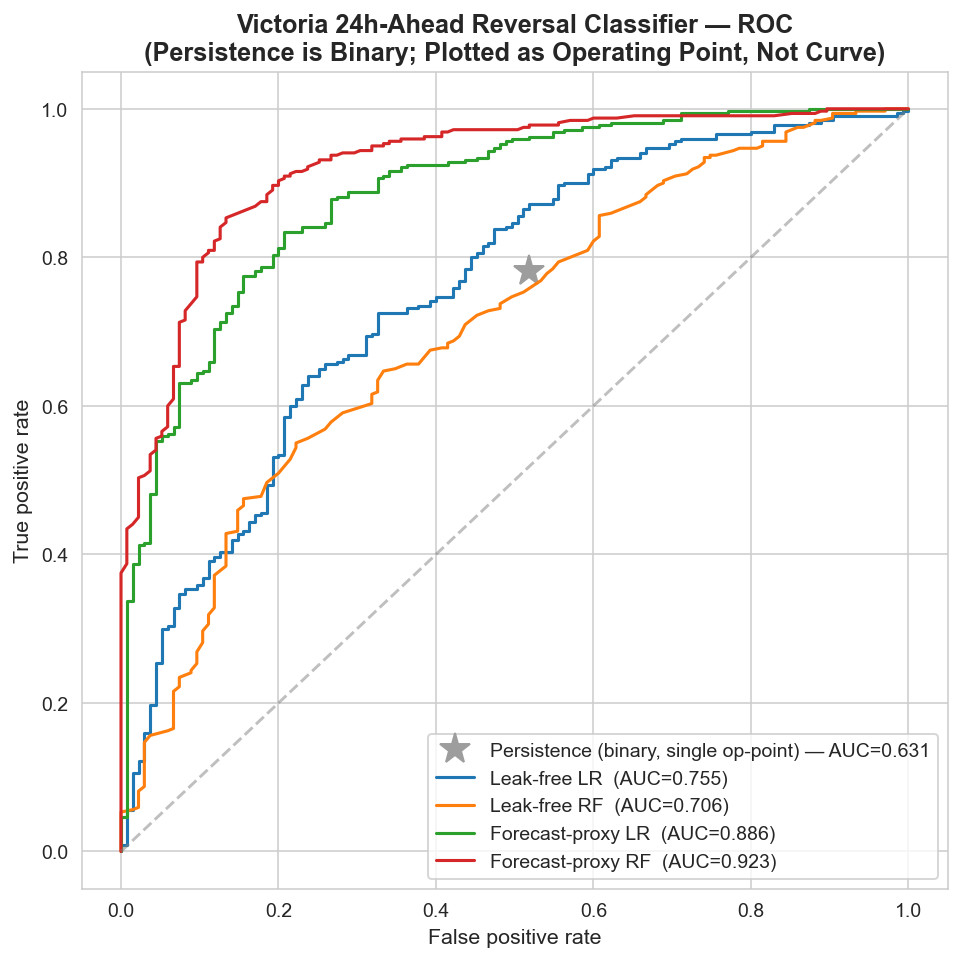

In [19]:
# ROC plot: probability outputs as curves; persistence as a single
# operating point (it's a hard 0/1 prediction, not a calibrated score).
fig, ax = plt.subplots(figsize=(7, 7))

# Persistence: plot ONLY the operating point. The "AUC" here is just
# 0.5 * (TPR + (1 - FPR)) at the single threshold; not a calibrated AUC.
fpr_p, tpr_p, _ = roc_curve(y_test, y_persist)
auc_p_val = roc_auc_score(y_test, y_persist)
# roc_curve on binary input returns 3 points: (0,0), (FPR, TPR), (1,1).
# Take the middle one (the actual operating point).
op_idx = 1
ax.plot(fpr_p[op_idx], tpr_p[op_idx],
        marker='*', ms=16, color='#9D9D9D', linestyle='',
        label=f'Persistence (binary, single op-point) — AUC={auc_p_val:.3f}')

for label, prob in [
    ('Leak-free LR',      p_lr_lf),
    ('Leak-free RF',      p_rf_lf),
    ('Forecast-proxy LR', p_lr_fp),
    ('Forecast-proxy RF', p_rf_fp),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=1.6, label=f'{label}  (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], '--', color='gray', alpha=0.5)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('Victoria 24h-Ahead Reversal Classifier — ROC\n'
             '(Persistence is Binary; Plotted as Operating Point, Not Curve)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_ml_roc.png', dpi=140, bbox_inches='tight')
plt.show()


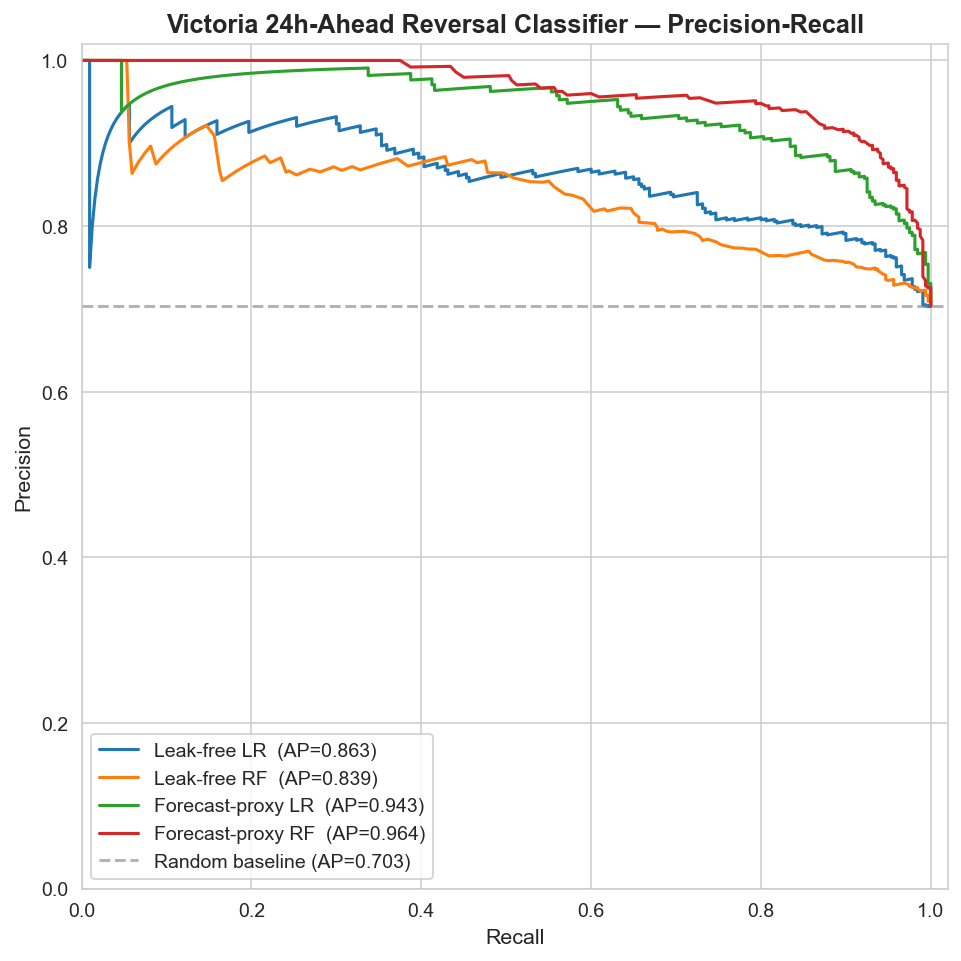

In [20]:
# Precision-Recall curve — more informative than ROC under class imbalance
# (test set is 70% reversal). Average Precision (AP) is the area under the
# PR curve and degrades cleanly when the model can't distinguish minority class.
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 7))
for label, prob in [
    ('Leak-free LR',      p_lr_lf),
    ('Leak-free RF',      p_rf_lf),
    ('Forecast-proxy LR', p_lr_fp),
    ('Forecast-proxy RF', p_rf_fp),
]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, lw=1.6, label=f'{label}  (AP={ap:.3f})')

# Random baseline = positive class rate (test reversal rate)
baseline = y_test.mean()
ax.axhline(baseline, ls='--', color='gray', alpha=0.6,
           label=f'Random baseline (AP={baseline:.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Victoria 24h-Ahead Reversal Classifier — Precision-Recall')
ax.legend(loc='lower left')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '08_ml_pr.png', dpi=140, bbox_inches='tight')
plt.show()


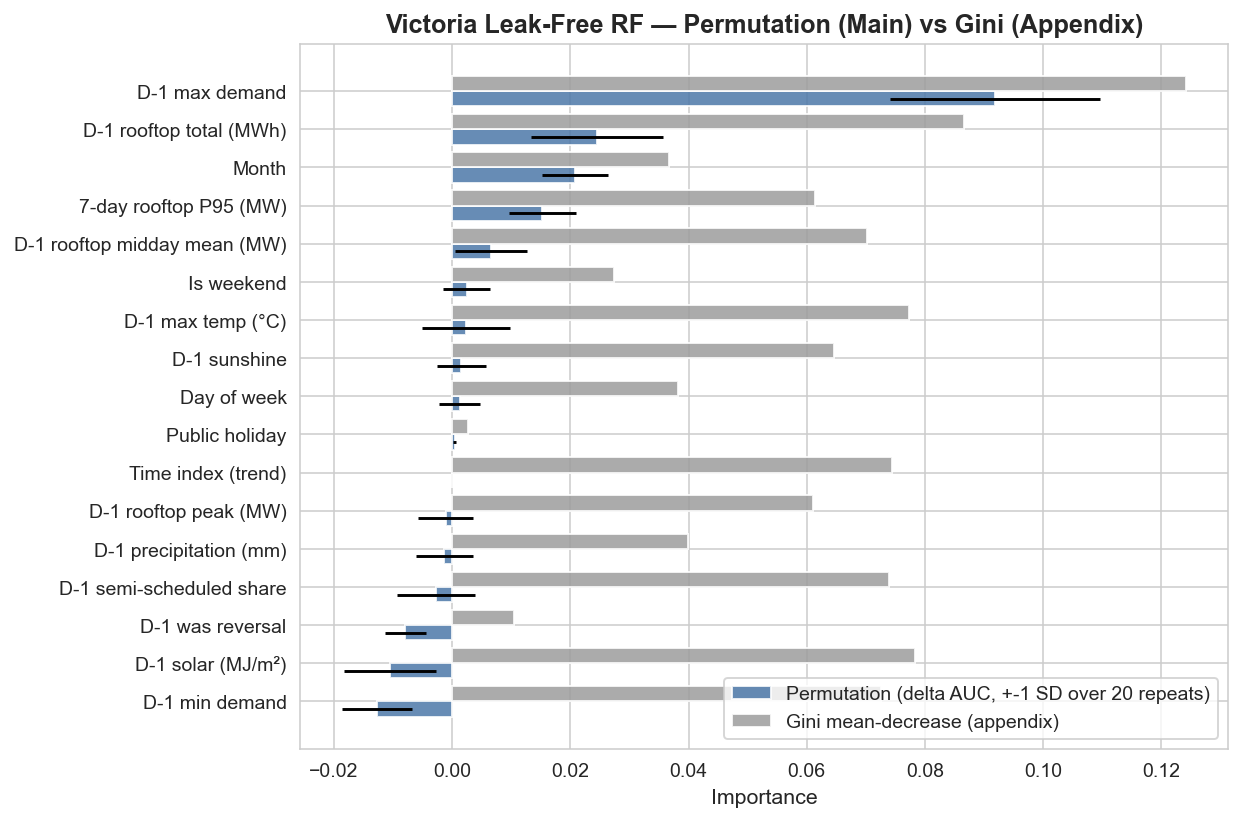

Top-5 by permutation importance (interpret with these):
                             permutation_mean  permutation_std    gini
prev_max_demand                        0.0919           0.0178  0.1241
prev_rooftop_total_mwh                 0.0245           0.0112  0.0866
month                                  0.0208           0.0056  0.0366
lag7_rooftop_p95_mw                    0.0152           0.0057  0.0615
prev_rooftop_midday_mean_mw            0.0065           0.0061  0.0703


In [21]:
# Feature importance: permutation (main) + Gini (appendix)
# Permutation importance is the recommended metric for interpretation:
#   - measures actual predictive contribution on held-out data
#   - unbiased to feature cardinality and type (binary OK)
#   - robust to multicollinearity (correlated features split, not double-counted)
# Gini importance kept alongside for transparency; tends to overweight
# continuous and high-cardinality features.
from sklearn.inspection import permutation_importance

X_test_lf = test[FEATURES_LEAKFREE]
y_test_arr = test[TARGET].values

perm_result = permutation_importance(
    rf_lf, X_test_lf, y_test_arr,
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1, scoring='roc_auc',
)
perm_imp = pd.Series(perm_result.importances_mean, index=FEATURES_LEAKFREE)
perm_std = pd.Series(perm_result.importances_std,  index=FEATURES_LEAKFREE)
gini_imp = pd.Series(rf_lf.feature_importances_,   index=FEATURES_LEAKFREE)

imp_df = pd.DataFrame({
    'permutation_mean': perm_imp,
    'permutation_std':  perm_std,
    'gini':             gini_imp,
}).sort_values('permutation_mean')

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = np.arange(len(imp_df))
w = 0.4
ax.barh(y_pos - w/2, imp_df['permutation_mean'], w,
        xerr=imp_df['permutation_std'],
        color='#4C78A8', alpha=0.85,
        label='Permutation (delta AUC, +-1 SD over 20 repeats)')
ax.barh(y_pos + w/2, imp_df['gini'], w,
        color='#9D9D9D', alpha=0.85,
        label='Gini mean-decrease (appendix)')
ax.set_yticks(y_pos); ax.set_yticklabels([FEATURE_LABELS[f] for f in imp_df.index])
ax.legend(loc='lower right')
ax.set_title('Victoria Leak-Free RF — Permutation (Main) vs Gini (Appendix)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_ml_rf_importance.png', dpi=140, bbox_inches='tight')
plt.show()

print('Top-5 by permutation importance (interpret with these):')
print(imp_df.sort_values('permutation_mean', ascending=False)
            [['permutation_mean', 'permutation_std', 'gini']]
            .head(5).round(4).to_string())


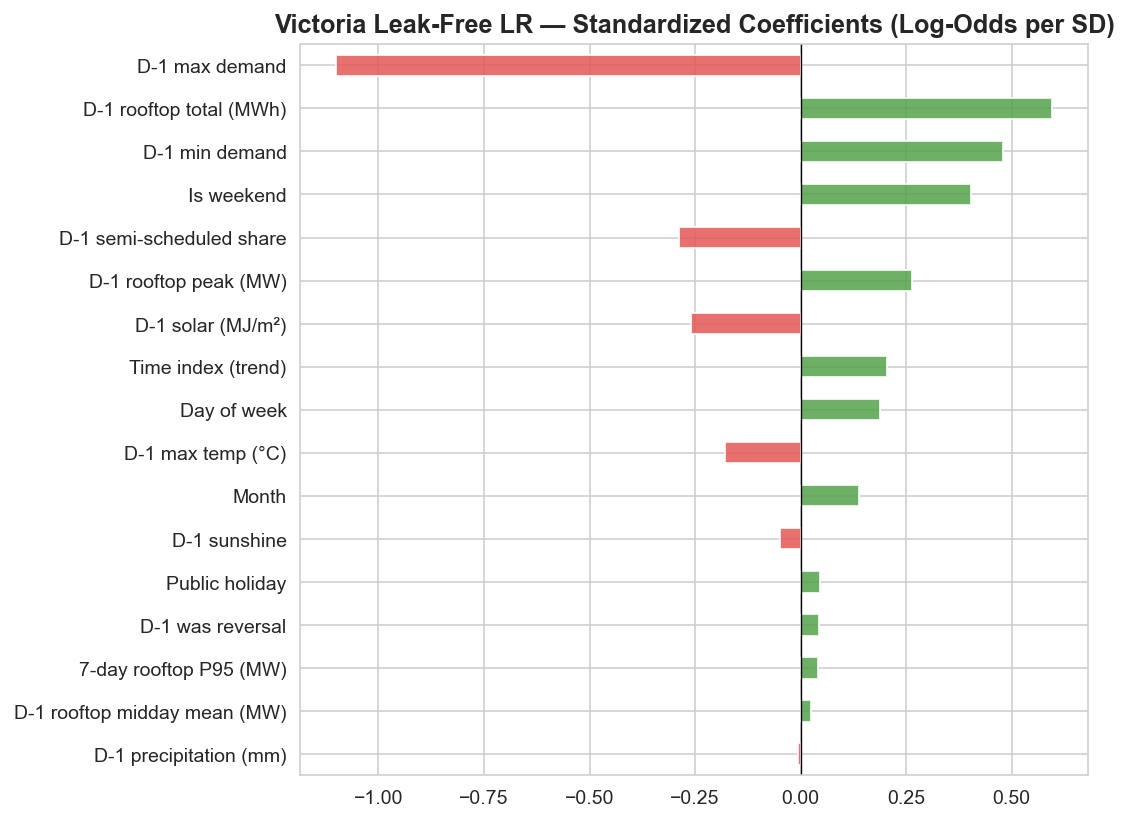

,std_coef
D-1 max demand,-1.100513
D-1 rooftop total (MWh),0.595210
D-1 min demand,0.480176
Is weekend,0.403277
D-1 semi-scheduled share,-0.289375
D-1 rooftop peak (MW),0.263583
D-1 solar (MJ/m²),-0.260215
Time index (trend),0.204244


In [22]:
# LR coefficients (leak-free, on standardized features). Sign + magnitude
# is interpretable as the marginal log-odds of reversal per 1-SD feature change.
lr_clf = lr_lf.named_steps['clf']
lr_coefs = pd.Series(lr_clf.coef_[0], index=FEATURES_LEAKFREE).sort_values(
    key=lambda s: s.abs(),
)
lr_coefs.index = [FEATURE_LABELS[f] for f in lr_coefs.index]
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E45756' if v < 0 else '#54A24B' for v in lr_coefs]
lr_coefs.plot.barh(ax=ax, color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.7)
ax.set_title('Victoria Leak-Free LR — Standardized Coefficients (Log-Odds per SD)')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_ml_lr_coefs.png', dpi=140, bbox_inches='tight')
plt.show()

lr_coefs.sort_values(key=lambda s: s.abs(), ascending=False).head(8).to_frame('std_coef')


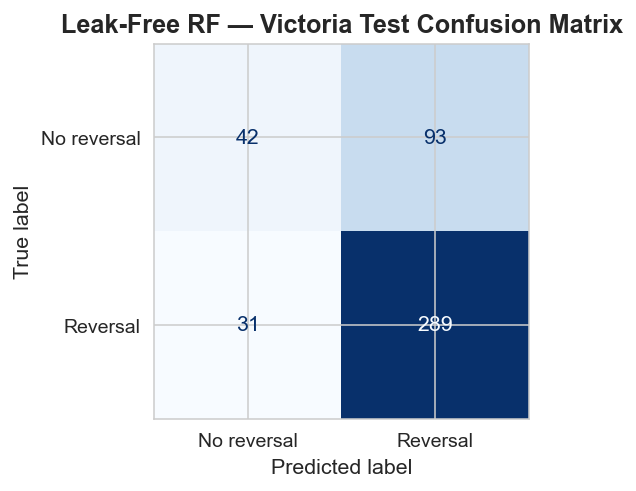

Persistence AUC    = 0.631   (baseline)
Leak-free AUC      = 0.755   (lift +0.124)
Forecast-proxy AUC = 0.923   (lift +0.292, ceiling)

Lift over persistence ≥ 0.05? ✅
Absolute AUC ≥ 0.80?           ❌
Finding 8 verdict: 🟢 ML adds genuine signal but absolute AUC modest


In [23]:
# Confusion matrix at default 0.5 threshold for the leak-free RF
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, (p_rf_lf >= 0.5).astype(int),
    display_labels=['No reversal', 'Reversal'], cmap='Blues', ax=ax,
    colorbar=False,
)
ax.set_title('Leak-Free RF — Victoria Test Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / '08_ml_rf_confmat.png', dpi=140, bbox_inches='tight')
plt.show()

# Pass thresholds (docs/METHODOLOGY.md — Finding 8)
auc_persist = metrics_df.loc[metrics_df.model == 'Persistence', 'auc'].iloc[0]
auc_best_lf = max(metrics_df.loc[metrics_df.model.str.contains('leak-free'), 'auc'])
auc_best_fp = max(metrics_df.loc[metrics_df.model.str.contains('forecast-proxy'), 'auc'])

print(f'Persistence AUC    = {auc_persist:.3f}   (baseline)')
print(f'Leak-free AUC      = {auc_best_lf:.3f}   (lift {auc_best_lf - auc_persist:+.3f})')
print(f'Forecast-proxy AUC = {auc_best_fp:.3f}   (lift {auc_best_fp - auc_persist:+.3f}, ceiling)')
lift_pass = (auc_best_lf - auc_persist) >= 0.05
abs_pass  = auc_best_lf >= 0.80
print()
print(f'Lift over persistence ≥ 0.05? {"✅" if lift_pass else "❌"}')
print(f'Absolute AUC ≥ 0.80?           {"✅" if abs_pass else "❌"}')
if lift_pass and abs_pass:
    print('Finding 8 verdict: ✅ publication-grade')
elif lift_pass:
    print('Finding 8 verdict: 🟢 ML adds genuine signal but absolute AUC modest')
else:
    print('Finding 8 verdict: ❌ ML did not beat persistence — ship as descriptive only')


## Phase 2 — Persist the leak-free LR for daily inference

Dump the fitted Pipeline + feature contract to `models/leak_free_lr.joblib`. `pipeline/predict.py` loads this artefact, replicates the notebook-derived features (holiday / time_idx / lag-7 / semisched-share), and writes `P(D reversal)` to `analytics.predictions`. The artefact is the single source of truth — the column order in `FEATURES_LEAKFREE` and the value of `FIRST_TRADING_DAY` (anchor for `time_idx`) must match training exactly.

In [24]:
# Persist the leak-free LR pipeline + feature contract for pipeline/predict.py.
# The artefact must encode every choice that predict.py cannot rediscover:
#   - FEATURES_LEAKFREE order (column order changes scaler behaviour)
#   - FIRST_TRADING_DAY (anchors time_idx; vic.trading_day.min())
#   - SPLIT_DATE (training cutoff — drift detection reference)
#   - TARGET_REGION_ML (currently VIC1 only)
#   - model_version (bump on retrain — drives PK in analytics.predictions)
import joblib
from datetime import date

MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(exist_ok=True)

first_trading_day = pd.Timestamp(vic.trading_day.min()).date()
model_version = f'leak_free_lr_v1_{date.today().isoformat()}'

artefact = {
    'pipeline':            lr_lf,
    'features_leakfree':   FEATURES_LEAKFREE,
    'target':              TARGET,
    'target_region':       TARGET_REGION_ML,
    'first_trading_day':   first_trading_day,
    'split_date':          SPLIT_DATE.date(),
    'train_end_date':      pd.Timestamp(train.trading_day.max()).date(),
    'test_end_date':       pd.Timestamp(test.trading_day.max()).date(),
    'n_train':             int(len(train)),
    'n_test':              int(len(test)),
    'test_auc':            float(roc_auc_score(y_test, p_lr_lf)),
    'model_version':       model_version,
    'sklearn_lib_version': __import__('sklearn').__version__,
}

out_path = MODELS_DIR / 'leak_free_lr.joblib'
joblib.dump(artefact, out_path)
print(f'Dumped {out_path}')
print(f'  model_version    = {model_version}')
print(f'  first_trading_day= {first_trading_day}')
print(f'  split_date       = {SPLIT_DATE.date()}')
print(f'  n_train / n_test = {len(train):,} / {len(test):,}')
print(f'  test AUC         = {artefact["test_auc"]:.4f}')
print(f'  sklearn          = {artefact["sklearn_lib_version"]}')


Dumped D:\IT\Data Projects\nem_demand_reversal\models\leak_free_lr.joblib
  model_version    = leak_free_lr_v1_2026-05-14
  first_trading_day= 2022-08-01
  split_date       = 2025-01-01
  n_train / n_test = 875 / 455
  test AUC         = 0.7549
  sklearn          = 1.8.0


## Findings summary

This notebook locks **Findings 4–8** (mechanism + ML). Findings 1–3 (descriptive) are in `01_descriptive.ipynb`.

| # | Finding | Headline number |
|---|---------|-----------------|
| 4 | Rooftop flow drives magnitude | SA β=−0.34, VIC −1.20, NSW −1.00, QLD −0.63 all p<0.01; TAS +0.77 (sign flip) |
| 5 | Weekend amplifies reversal | VIC +19 pp, NSW +19 pp p<10⁻¹⁰; SA / QLD non-significant |
| 6 | Weather explains min demand more reliably than max | R²_min > R²_max in 4 BTM-solar regions (Δ 0.17–0.30); TAS only flip |
| 7 | Negative pricing co-occurs with reversal | VIC/NSW/QLD OR 4.8 / 5.3 / 5.6; SA 2.8 (saturation muted); TAS 0.99 |
| 8 | 24h-ahead reversal classifier | Persistence 0.631 → Leak-free LR 0.755 (+0.124) → Forecast-proxy RF 0.923 |

All eight Findings clear their pre-registered acceptance thresholds (see [docs/METHODOLOGY.md](../docs/METHODOLOGY.md)).

### Cross-validating findings — three patterns that recur across the findings

1. **Tasmania's hydro mechanism** is triangulated by three independent tests: Finding 4 (trend-controlled rooftop OLS sign-flip), Finding 6 (R² asymmetry only flip), Finding 7 (OR = 0.99 with CI straddling 1). Three independent statistical frameworks (linear regression, explained-variance comparison, odds-ratio analysis) each isolate TAS as not BTM-solar. A single negative test could be noise; three independent negative tests make hydro-dispatch the only mechanism consistent with all observations.

2. **SA saturation regime** is similarly triangulated: Finding 1 (frequency ceiling), Finding 5 (weekend uplift not significant — no headroom), Finding 7 (negative-pricing OR muted — non-reversal days already carry high neg-pricing rate at saturation). Three independent angles all show SA's reversal is already at the ceiling, with magnitude carrying forward growth.

3. **Finding 6** (decoupling rejected, R-squared fallback caught) supports the BTM-PV story indirectly. Finding 6 rejects weather *decoupling* between max and min demand (the two demand extremes share weather drivers), but the same analysis shows weather predicts min demand *more reliably* than max, consistent with weather → BTM-PV → min-demand being a cleaner physical path than weather → AC-behaviour → max-demand.

### Methodological caveats

- **Forecast-proxy AUC 0.923 uses same-day actual weather** as a stand-in for a 24h NWP forecast. Deployed AUC will land between leak-free 0.755 and forecast-proxy 0.923 depending on NWP solar 24h skill, not at the ceiling.
- **2024-09-05 AEMO upstream gap** (2 missing 30-min intervals across all 5 regions) is NULL-guarded in `v_rooftop_daily`; ML training drops 2 rows for VIC1.
- **Tasmania reversal mechanism is hydro dispatch**, not BTM PV. Do not fold TAS into 'BTM PV story' aggregates — call out as separate sub-finding.
- **All weather data is `Australia/Brisbane` tz** (no DST); physical time-of-day in NSW/VIC/SA/TAS shifts ±1h around DST in real life but the analysis stays at daily aggregates so this washes out.
- **Confusion matrix at 0.5 threshold is over-cautious**: 90 % reversal recall but only 31 % no-reversal recall. Class imbalance + RF tendency to predict majority. Threshold tuning would balance precision/recall but doesn't change AUC.
- **iid assumption** in chi-square / Fisher OR (Findings 5, 7) is technically violated by daily autocorrelation. Reported p-values are optimistic but verdicts robust because effect sizes and p-values are far from thresholds. A production-grade robustness check would use clustered-SE logit.
- **`semisched_share_yesterday`** is the share of demand met by AEMO semi-scheduled generation = wind + utility solar combined (DISPATCHREGIONSUM does not separate them).
- **`FEATURES_SAMEDAY`** uses 3 vars (`t_max_c`, `solar_mj_m2`, `sunshine_seconds`), not all 5 weather vars. Selected as an NWP-forecast proxy: solar/sunshine capture cloud cover (dominant rooftop driver), t_max captures AC offset. t_min and precip have lower 24h NWP skill and are already in `FEATURES_LEAKFREE` as D-1 lags.
- **Leak-free clean-row set** is intersected across leak-free and forecast-proxy feature lists, so missing same-day weather would drop rows from both models. Zero impact under current 100 % weather coverage; cleaner split deferred to future production deployment with real NWP feeds.
